In [ ]:
!pip install pandas numpy scikit-learn matplotlib

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

In [ ]:
df = pd.read_csv("/content/diabetic_data_sample.csv")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (500, 12)

First 5 Rows:
   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0                 7                  58               4               26   
1                 4                  58               5               28   
2                13                  86               1               21   
3                11                  49               2                7   
4                 8                  52               2               17   

   number_outpatient  number_emergency  number_inpatient  number_diagnoses  \
0                  2                 1                 2                 1   
1                  1                 0                 1                 9   
2                  1                 0                 2                 6   
3                  2                 0                 2                 2   
4                  1                 0                 3                 5   

   diag_1 diag_2  diag_3 readmitte

In [ ]:
# Diagnosis columns
diagnosis_cols = ["diag_1", "diag_2", "diag_3"]

# Count available diagnosis codes
# '?' represents missing diagnosis information

df["diagnosis_count"] = (
    df[diagnosis_cols] != "?"
).sum(axis=1)

print("Diagnosis Count Created!")

print(df[["diag_1", "diag_2", "diag_3", "diagnosis_count"]].head())

Diagnosis Count Created!
   diag_1 diag_2  diag_3  diagnosis_count
0   428.0    786  250.00                3
1   401.9    428     786                3
2   428.0    428   401.9                3
3   401.9  401.9     428                3
4   428.0    786     428                3


In [ ]:
features = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "diagnosis_count"
]

X = df[features].copy()

print("Selected Features:")
print(X.head())

Selected Features:
   time_in_hospital  num_lab_procedures  num_procedures  num_medications  \
0                 7                  58               4               26   
1                 4                  58               5               28   
2                13                  86               1               21   
3                11                  49               2                7   
4                 8                  52               2               17   

   number_outpatient  number_emergency  number_inpatient  number_diagnoses  \
0                  2                 1                 2                 1   
1                  1                 0                 1                 9   
2                  1                 0                 2                 6   
3                  2                 0                 2                 2   
4                  1                 0                 3                 5   

   diagnosis_count  
0                3  
1            

In [ ]:
# 1 = Readmitted within 30 days
# 0 = Not readmitted within 30 days

y = (df["readmitted"] == "<30").astype(int)

print("Target Distribution:")
print(y.value_counts())

print("\nTarget Meaning:")
print("0 = No Readmission")
print("1 = Readmission within 30 days")

Target Distribution:
readmitted
0    350
1    150
Name: count, dtype: int64

Target Meaning:
0 = No Readmission
1 = Readmission within 30 days


In [ ]:
# Replace '?' with NaN
X = X.replace("?", np.nan)

# Convert values to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Fill missing values with median
X = X.fillna(X.median())

print("Missing Values After Cleaning:")
print(X.isnull().sum())

Missing Values After Cleaning:
time_in_hospital      0
num_lab_procedures    0
num_procedures        0
num_medications       0
number_outpatient     0
number_emergency      0
number_inpatient      0
number_diagnoses      0
diagnosis_count       0
dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 9)
Testing Data: (100, 9)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature Standardization Completed!")

Feature Standardization Completed!


In [ ]:
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

print("Logistic Regression Model Created!")

Logistic Regression Model Created!


In [ ]:
model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


In [ ]:
# Predict probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Classification threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

print("Prediction Completed!")

Prediction Completed!


In [ ]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.4962


In [ ]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Readmission",
            "Readmission"
        ]
    )
)

Classification Report:
                precision    recall  f1-score   support

No Readmission       0.70      0.61      0.66        70
   Readmission       0.31      0.40      0.35        30

      accuracy                           0.55       100
     macro avg       0.51      0.51      0.50       100
  weighted avg       0.59      0.55      0.56       100



Confusion Matrix:
[[43 27]
 [18 12]]


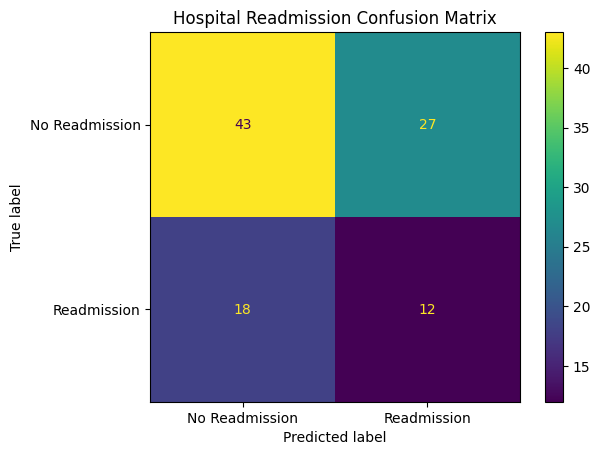

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Readmission",
        "Readmission"
    ]
)

disp.plot()

plt.title("Hospital Readmission Confusion Matrix")

plt.show()

In [ ]:
tn, fp, fn, tp = cm.ravel()

print("Clinical Error Analysis")

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Clinical Error Analysis
True Negatives: 43
False Positives: 27
False Negatives: 18
True Positives: 12


In [ ]:
# Illustrative costs only
# These are NOT real hospital costs

cost_fn = 100
cost_fp = 10

total_cost = (
    fn * cost_fn
) + (
    fp * cost_fp
)

print("Clinical Cost Analysis")

print(
    "Cost of False Negatives:",
    fn * cost_fn
)

print(
    "Cost of False Positives:",
    fp * cost_fp
)

print(
    "Total Illustrative Cost:",
    total_cost
)

Clinical Cost Analysis
Cost of False Negatives: 1800
Cost of False Positives: 270
Total Illustrative Cost: 2070


In [ ]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

print("ROC Curve Data Generated!")

ROC Curve Data Generated!


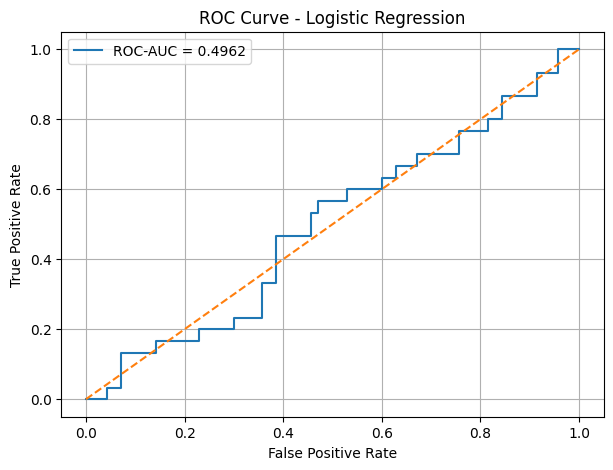

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.grid()

plt.show()

In [ ]:
print("Conclusion:")

print(
    "Logistic Regression with L2 regularization "
    "was used to predict 30-day hospital readmission."
)

print(
    "The model was evaluated using ROC-AUC "
    "and classification metrics."
)

print(
    "False negatives and false positives were "
    "analyzed using the confusion matrix."
)

print(
    "Illustrative costs were used to demonstrate "
    "the impact of prediction errors."
)

Conclusion:
Logistic Regression with L2 regularization was used to predict 30-day hospital readmission.
The model was evaluated using ROC-AUC and classification metrics.
False negatives and false positives were analyzed using the confusion matrix.
Illustrative costs were used to demonstrate the impact of prediction errors.
